# DataSet Merging and Feature Engineering

In [1]:
# === Ler + fundir CSVs e colapsar por ID_Aluno 
import pandas as pd
import numpy as np
import re
from pathlib import Path

EMB_PATH = Path("../data/processed/08.FRAIL_with_tsvd_10dim.csv")
LLM_PATH = Path("../data/processed/09.llm.csv")
DROP_PERCENTILES = False  # True se quiseres já remover colunas Percentil*

# 1) Ler
emb = pd.read_csv(EMB_PATH)
llm = pd.read_csv(LLM_PATH)
print(f"Loaded embeddings: {EMB_PATH} | shape={emb.shape}")
print(f"Loaded LLM:        {LLM_PATH} | shape={llm.shape}")

# 2) Chaves obrigatórias
for k in ["ID_Aluno", "Momento"]:
    if k not in emb.columns or k not in llm.columns:
        raise KeyError(f"Missing key '{k}' in one of the files. emb has={k in emb.columns}, llm has={k in llm.columns}")

# 3) Tipos coerentes para as chaves
for k in ["ID_Aluno", "Momento"]:
    emb[k] = pd.to_numeric(emb[k], errors="coerce").astype("Int64")
    llm[k] = pd.to_numeric(llm[k], errors="coerce").astype("Int64")

# 4) Deduplicar por (ID_Aluno, Momento)
if emb.duplicated(subset=["ID_Aluno","Momento"]).any():
    emb = (emb.sort_values(["ID_Aluno","Momento"])
              .drop_duplicates(subset=["ID_Aluno","Momento"], keep="first"))
if llm.duplicated(subset=["ID_Aluno","Momento"]).any():
    llm = (llm.sort_values(["ID_Aluno","Momento"])
              .drop_duplicates(subset=["ID_Aluno","Momento"], keep="first"))

# 5) Merge (left = manter todas as linhas do embeddings)
df = emb.merge(llm, on=["ID_Aluno","Momento"], how="left", suffixes=("", "_llmdup"))
dup_cols = [c for c in df.columns if c.endswith("_llmdup")]
if dup_cols:
    df = df.drop(columns=dup_cols)

# 6) (Opcional) remover Percentil*
if DROP_PERCENTILES:
    pct_cols = [c for c in df.columns if re.search(r"percentil|percentile", c, flags=re.I)]
    if pct_cols:
        df = df.drop(columns=pct_cols)
        print(f"Dropped percentile columns: {len(pct_cols)}")

print(f"Merged shape: {df.shape}")

# 7) Colapsar para 1 linha por ID_Aluno com lógica causal
#    - Nunca caiu             → primeiro momento, label=0
#    - Caiu nalgum momento    → último momento ANTES da primeira queda, label=1
#    - Só tem 1 registo e esse tem queda, ou só tem registos com queda → excluir
PREF_FALL_COL = "Quedas_ultimos_12meses"
if PREF_FALL_COL not in df.columns:
    raise KeyError(f"Column '{PREF_FALL_COL}' not found after merge.")

df["Momento"] = pd.to_numeric(df["Momento"], errors="coerce")
df[PREF_FALL_COL] = pd.to_numeric(df[PREF_FALL_COL], errors="coerce").fillna(0).astype(int)

before_shape = df.shape
n_multi = (df["ID_Aluno"].value_counts() > 1).sum()
n_excluded = 0

df = df.sort_values(["ID_Aluno", "Momento"]).reset_index(drop=True)

rows_to_keep = []
for id_aluno, group in df.groupby("ID_Aluno"):
    group = group.sort_values("Momento")

    fall_moments   = group[group[PREF_FALL_COL] == 1]["Momento"]
    no_fall_before = group[group[PREF_FALL_COL] == 0]

    if len(fall_moments) == 0:
        # Nunca caiu → primeiro momento, label=0
        rows_to_keep.append(group.iloc[0].copy())

    else:
        first_fall   = fall_moments.min()
        before_fall  = no_fall_before[no_fall_before["Momento"] < first_fall]

        if len(before_fall) == 0:
            # Sem registo limpo antes da queda → excluir
            n_excluded += 1
            continue

        # Último momento antes da primeira queda, label=1
        row = before_fall.iloc[-1].copy()
        row[PREF_FALL_COL] = 1
        rows_to_keep.append(row)

df = pd.DataFrame(rows_to_keep).reset_index(drop=True)

print(f"Collapsed per ID_Aluno: {before_shape} -> {df.shape} | IDs com >1 registo: {n_multi}")
print(f"IDs excluídos (sem registo pré-queda): {n_excluded}")
print(f"Com queda  (label=1): {(df[PREF_FALL_COL] == 1).sum()}")
print(f"Sem queda  (label=0): {(df[PREF_FALL_COL] == 0).sum()}")



Loaded embeddings: ..\data\processed\08.FRAIL_with_tsvd_10dim.csv | shape=(6705, 111)
Loaded LLM:        ..\data\processed\09.llm.csv | shape=(6705, 74)
Merged shape: (6705, 115)
Collapsed per ID_Aluno: (6705, 115) -> (2186, 115) | IDs com >1 registo: 2051
IDs excluídos (sem registo pré-queda): 658
Com queda  (label=1): 394
Sem queda  (label=0): 1792


In [2]:

import re
import numpy as np
import pandas as pd

df = df.copy()

# 1) Corrigir typo comum: "tentaiva" -> "tentativa"
df = df.rename(columns={"HANDGRIP_DIREITA_tentaiva1": "HANDGRIP_DIREITA_tentativa1"})

# 2) Listar todas as colunas de tentativas (direita e esquerda)
hand_right_attempts = [c for c in df.columns if re.fullmatch(r"HANDGRIP_DIREITA_tentativa[123]", c)]
hand_left_attempts  = [c for c in df.columns if re.fullmatch(r"HANDGRIP_ESQUERDA_tentativa[123]", c)]

# 3) Calcular o melhor por mão (máximo nas tentativas disponíveis)
if hand_right_attempts:
    df["HANDGRIP_DIREITA_max"] = df[hand_right_attempts].astype(float).max(axis=1, skipna=True)

if hand_left_attempts:
    df["HANDGRIP_ESQUERDA_max"] = df[hand_left_attempts].astype(float).max(axis=1, skipna=True)

# 4) Calcular o melhor global (entre as duas mãos)
cands = []
if "HANDGRIP_DIREITA_max" in df:  cands.append("HANDGRIP_DIREITA_max")
if "HANDGRIP_ESQUERDA_max" in df: cands.append("HANDGRIP_ESQUERDA_max")
if cands:
    df["HANDGRIP_BEST"] = df[cands].max(axis=1, skipna=True)

# 5) Remover colunas de tentativas e médias antigas (se existirem)
drop_hand_cols = []
drop_hand_cols += hand_right_attempts + hand_left_attempts
drop_hand_cols += [c for c in ["HANDGRIP_DIREITA_mean", "HANDGRIP_ESQUERDA_mean"] if c in df.columns]

if drop_hand_cols:
    df = df.drop(columns=drop_hand_cols, errors="ignore")

# (opcional) verificação rápida
cols_to_show = [c for c in ["HANDGRIP_DIREITA_max","HANDGRIP_ESQUERDA_max","HANDGRIP_BEST"] if c in df.columns]
print("HANDGRIP colunas criadas:", cols_to_show)

df = df.drop(columns=["HANDGRIP_DIREITA_max", "HANDGRIP_ESQUERDA_max"], errors="ignore")


HANDGRIP colunas criadas: ['HANDGRIP_DIREITA_max', 'HANDGRIP_ESQUERDA_max', 'HANDGRIP_BEST']


In [3]:

import re
import numpy as np
import pandas as pd

df = df.copy()  # work on a copy


kept_all, dropped_all, created_all = [], [], []

def process_metric(df, attempts, best_col=None, mean_col=None, name="metric"):
    """Keep BEST if present; otherwise create/keep MEAN; drop attempts."""
    local_kept, local_dropped, local_created = [], [], []
    atts = [c for c in attempts if c in df.columns]

    if best_col and (best_col in df.columns):
        # BEST exists → keep it, drop attempts (+ mean if already existed)
        if mean_col and (mean_col in df.columns):
            df = df.drop(columns=[mean_col], errors="ignore")
            local_dropped.append(mean_col)
        if atts:
            df = df.drop(columns=atts, errors="ignore")
            local_dropped += atts
        local_kept.append(best_col)
        print(f"[{name}] Keeping BEST '{best_col}'. Dropped attempts: {atts}"
              + (f" and mean '{mean_col}'" if mean_col in local_dropped else ""))
    else:
        # No BEST → compute/keep MEAN (if there are attempts), then drop attempts
        if atts:
            if mean_col:
                df[mean_col] = df[atts].astype(float).mean(axis=1, skipna=True)
                local_kept.append(mean_col); local_created.append(mean_col)
                print(f"[{name}] No BEST. Created/kept MEAN '{mean_col}'.")
            df = df.drop(columns=atts, errors="ignore")
            local_dropped += atts
            print(f"[{name}] Dropped attempts: {atts}")
        else:
            print(f"[{name}] No BEST and no attempts found. Nothing to do.")

    kept_all.extend(local_kept); dropped_all.extend(local_dropped); created_all.extend(local_created)
    return df

# TUG (has Best_*)
df = process_metric(
    df,
    attempts=["TIMED_UP_AND_GO_Simples_tentativa1","TIMED_UP_AND_GO_Simples_tentativa2"],
    best_col="Best_TIMED_UP_AND_GO_Simples",
    mean_col="TIMED_UP_AND_GO_Simples_mean",
    name="TUG Simples"
)
df = process_metric(
    df,
    attempts=["TIMED_UP_AND_GO_Dupla_tarefa_tentativa1","TIMED_UP_AND_GO_Dupla_tarefa_tentativa2"],
    best_col="Best_TIMED_UP_AND_GO_Dupla_tarefa",
    mean_col="TIMED_UP_AND_GO_Dupla_tarefa_mean",
    name="TUG Dupla"
)

# Handgrip (no Best_* → keep MEAN, drop attempts) — tolerate typo 'tentaiva'
right_attempts = [c for c in df.columns if re.fullmatch(r"HANDGRIP_DIREITA_tent(at)?iva[123]", c)]
left_attempts  = [c for c in df.columns if re.fullmatch(r"HANDGRIP_ESQUERDA_tentativa[123]", c)]
df = process_metric(df, attempts=right_attempts, best_col=None, mean_col="HANDGRIP_DIREITA_mean", name="Handgrip Direita")
df = process_metric(df, attempts=left_attempts,  best_col=None, mean_col="HANDGRIP_ESQUERDA_mean", name="Handgrip Esquerda")

# Defensive: drop any leftover attempt columns
left_tent = [c for c in df.columns if re.search(r"tentativa", c, flags=re.I)]
if left_tent:
    df = df.drop(columns=left_tent, errors="ignore"); dropped_all += left_tent
    print(f"Dropped leftover attempt cols: {left_tent}")

print("\nKept summary columns:", kept_all)
print("Created means:", created_all)
print("Dropped (sample):", dropped_all[:15], "... total:", len(dropped_all))


# 2) Drop Percentil* (case-insensitive)

pct_cols = [c for c in df.columns if re.search(r"(?i)^percentil|percentile", c)]
if pct_cols:
    df = df.drop(columns=pct_cols, errors="ignore")
    print(f"Dropped Percentil* columns: {len(pct_cols)}")


# 3) Build X, y — drop leakage + project-specific cols

TARGET = "Quedas_ultimos_12meses"
y = df[TARGET]

# IDs / dates
drop_ids_dates = ["ID_Aluno","Data_avaliacao","Data_nascimento"]

# Hospitalization-related (remove entirely)
drop_hosp = [
    "Quedas_12meses_Hospitalizado_Sim_Não",
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Assistencia_hospitalar_Sim_Não",
]

# Falls-related info known AFTER the outcome (remove) + their LLM/Embeddings
drop_falls_post = [
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Momento"
    # LLM scores from those texts
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade",
    "Quedas_12meses_Lesao_Gravidade",
    # TSVD embeddings from those texts
    *[f"Q12M_Sit_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesTipo_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesLocal_Emb_{i}" for i in range(10)],
]

# Project rule
drop_project_rules = ["@6_MIN_ANDAR_Desistiu"]

# Extra removals (your choices)
drop_extra = [
    "Momento",
    "Quedas_12meses_Medo_cair_Sim_N_o",
    "Local_de_Avaliacao",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Percentil_SIT_TO_STAND_Repetiçoes",
    "Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros",   # your request
    "@6_MIN_ANDAR_N_voltas_completas",
    "Escolaridade"
]

# Assemble and drop
drop_cols = drop_ids_dates + drop_hosp + drop_falls_post + drop_project_rules + drop_extra + [TARGET]
existing_to_drop = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=existing_to_drop, errors="ignore")

print("\n=== X/y summary ===")
print("Target:", TARGET)
print("Dropped columns (present):", len(existing_to_drop))
print(existing_to_drop)
print("X shape:", X.shape, "| y shape:", y.shape)


# 4) Final sanity: no fall text/emb/LLM leakage in X

raw_fall_texts = ["Quedas_12meses_Situacao","Quedas_12meses_Lesao_Tipo","Quedas_12meses_Lesao_Local"]
embedded_cols = [c for c in df.columns if c.startswith(("Q12M_Sit_Emb_","Q12M_LesTipo_Emb_","Q12M_LesLocal_Emb_"))]
llm_cols = ["Quedas_12meses_Lesao_Gravidade","Quedas_12meses_Situacao_score","Quedas_12meses_Lesao_Local_Gravidade"]
leak_left = [c for c in raw_fall_texts + embedded_cols + llm_cols if c in X.columns]
print("\nStill in X (should be empty):", leak_left)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric columns ({}):".format(len(num_cols)))
print(num_cols[:40], "..." if len(num_cols) > 40 else "")
print("\nCategorical columns ({}):".format(len(cat_cols)))
print(cat_cols)



[TUG Simples] Keeping BEST 'Best_TIMED_UP_AND_GO_Simples'. Dropped attempts: ['TIMED_UP_AND_GO_Simples_tentativa1', 'TIMED_UP_AND_GO_Simples_tentativa2']
[TUG Dupla] Keeping BEST 'Best_TIMED_UP_AND_GO_Dupla_tarefa'. Dropped attempts: ['TIMED_UP_AND_GO_Dupla_tarefa_tentativa1', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2']
[Handgrip Direita] No BEST and no attempts found. Nothing to do.
[Handgrip Esquerda] No BEST and no attempts found. Nothing to do.
Dropped leftover attempt cols: ['HANDGRIP_DIREITA_tentativa_3']

Kept summary columns: ['Best_TIMED_UP_AND_GO_Simples', 'Best_TIMED_UP_AND_GO_Dupla_tarefa']
Created means: []
Dropped (sample): ['TIMED_UP_AND_GO_Simples_tentativa1', 'TIMED_UP_AND_GO_Simples_tentativa2', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa1', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2', 'HANDGRIP_DIREITA_tentativa_3'] ... total: 5
Dropped Percentil* columns: 4

=== X/y summary ===
Target: Quedas_ultimos_12meses
Dropped columns (present): 51
['ID_Aluno', 'Data_avaliacao', 'Dat

In the code above we merge the different features and eliminate the percentils since they need to be computed only on training data. Now we will try to use every variable available to predict quedas, except the ones that do not make sense like fear of falling, or things post falling, for example. And escolaridade e mmse educaçao

Besides that the handgrip tests, we kept only the better one since people can be left or right handed.

We also retained just one person, per momento, and focused on looking for more falls. This prevent data repetition, and gives a more balanced dataset.

## Logistic Regression

c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Continuous (scaled): 40
Binary (passthrough): 10
Categorical (OHE): 1
sv.values shape: (438, 75)
any finite SHAP values?: True


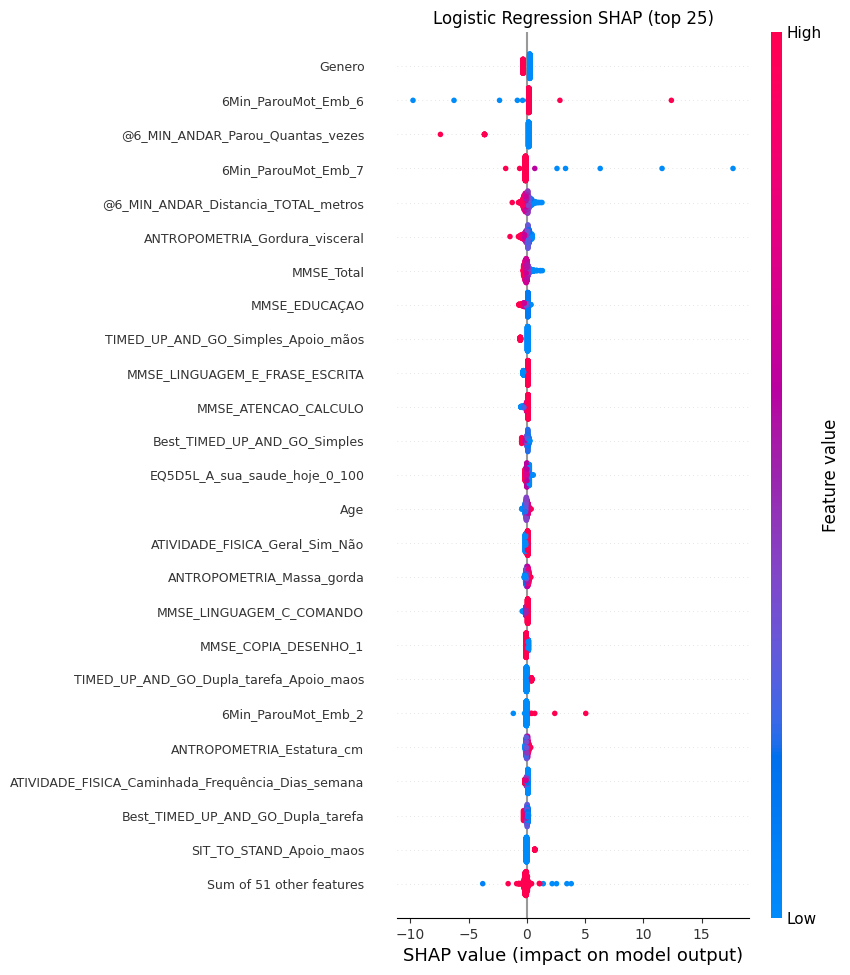

                                      feature      coef  odds_ratio
34                        6Min_ParouMot_Emb_6  0.989419    2.689670
46                    SIT_TO_STAND_Apoio_maos  0.708215    2.030364
67       @6_MIN_ANDAR_Parou_Motivo_dor joelho  0.503563    1.654606
51    @6_MIN_ANDAR_Parou_Motivo_Dor articular  0.469290    1.598859
45    TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos  0.422958    1.526470
30                        6Min_ParouMot_Emb_2  0.380775    1.463419
48             MMSE_LINGUAGEM_E_FRASE_ESCRITA  0.377361    1.458431
71   @6_MIN_ANDAR_Parou_Motivo_dor nos gemeos  0.370950    1.449111
52  @6_MIN_ANDAR_Parou_Motivo_Dor joelho e pé  0.325336    1.384495
41             ATIVIDADE_FISICA_Geral_Sim_Não  0.175056    1.191312
                                    feature      coef  odds_ratio
35                      6Min_ParouMot_Emb_7 -1.003948    0.366430
43       TIMED_UP_AND_GO_Simples_Apoio_mãos -0.629429    0.532896
13         @6_MIN_ANDAR_Parou_Quantas_vezes -0.601119 

In [4]:

from sklearn import __version__ as skver
from packaging.version import Version
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import shap
import matplotlib.pyplot as plt
# use sparse_output for newer sklearn, else sparse for older
if Version(skver) >= Version("1.2"):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

#  1) Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Column typing: continuous vs binary vs categorical
num_all = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# auto-detect binary numeric columns (values subset of {0,1} on train)
binary_cols, continuous_cols = [], []
for c in num_all:
    vals = pd.Series(X_train[c]).dropna().unique()
    # treat as binary if all values are within {0,1}
    if set(np.unique(vals)).issubset({0, 1}):
        binary_cols.append(c)
    else:
        continuous_cols.append(c)

print(f"Continuous (scaled): {len(continuous_cols)}")
print(f"Binary (passthrough): {len(binary_cols)}")
print(f"Categorical (OHE): {len(cat_cols)}")

# 3) Preprocessor
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), continuous_cols),
        ("bin", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
        ]), binary_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)
#  4) Model
logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=None,
    solver="lbfgs"
)

pipe = Pipeline([
    ("pre", pre),
    ("clf", logreg),
])

pipe.fit(X_train, y_train)

#  5) Get transformed matrices + feature names (for SHAP + plots)
X_train_t = pipe.named_steps["pre"].transform(X_train)
X_val_t   = pipe.named_steps["pre"].transform(X_val)


try:
    feat_names = pipe.named_steps["pre"].get_feature_names_out().tolist()
except Exception:
    # fallback: generic names
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

#  6) SHAP with LinearExplainer on the fitted linear model
# 
bg_idx = np.random.RandomState(42).choice(X_train_t.shape[0], size=min(1000, X_train_t.shape[0]), replace=False)
background = X_train_t[bg_idx]

explainer = shap.LinearExplainer(pipe.named_steps["clf"], background)
sv= explainer(X_val_t)
sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names,
)

# sanity checks
print("sv.values shape:", getattr(sv, "values", None).shape)
print("any finite SHAP values?:", np.isfinite(sv.values).any())



plt.close("all")


fig, ax = plt.subplots(figsize=(14, 9))
shap.plots.beeswarm(sv, max_display=25, show=False)


plt.yticks(fontsize=9)
plt.xticks(fontsize=10)
plt.subplots_adjust(left=0.35)   # increase if labels are still truncated (e.g., 0.40)

plt.title("Logistic Regression SHAP (top 25)")
plt.show()



#  8)  top coefficients (odds ratios)
coef = pipe.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feat_names, "coef": coef})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
print(coef_df.sort_values("coef", ascending=False).head(10))
print(coef_df.sort_values("coef", ascending=True).head(10))


AUROC   : 0.636
PR-AUC  : 0.260
Acc@0.5 : 0.621
F1@0.5  : 0.362

Best threshold (by F1): 0.43
F1@best: 0.383

Confusion @0.5
 [[225 134]
 [ 32  47]]

Confusion @best
 [[168 191]
 [ 15  64]]

Classification report @best
              precision    recall  f1-score   support

           0      0.918     0.468     0.620       359
           1      0.251     0.810     0.383        79

    accuracy                          0.530       438
   macro avg      0.585     0.639     0.502       438
weighted avg      0.798     0.530     0.577       438



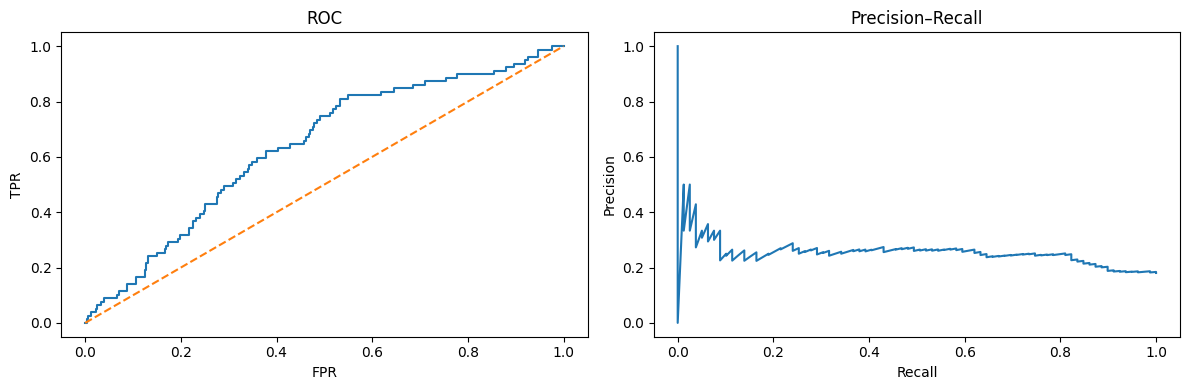

In [5]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt

# Predicted probabilities and default 0.5 labels
proba = pipe.predict_proba(X_val)[:, 1]
pred05 = (proba >= 0.5).astype(int)

# Core metrics
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# ---- Threshold tuning (maximize F1 on the validation set) ----
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
best_ix = np.nanargmax(f1s)
best_thr = thr[best_ix] if best_ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\nBest threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")

# Confusion matrices
print("\nConfusion @0.5\n", confusion_matrix(y_val, pred05))
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))

# Classification report @best
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# ---- Curves (ROC and PR) ----
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")
plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.tight_layout(); plt.show()


## XGBoost

Best iteration: 75
Best score (val): 0.6575226543492825

--- Métricas @0.5 ---
AUROC   : 0.658
PR-AUC  : 0.284
Acc@0.5 : 0.651
F1@0.5  : 0.360

--- Threshold tuning ---
Best threshold (by F1): 0.482
F1@best: 0.369

Confusion @0.5
 [[242 117]
 [ 36  43]]

Confusion @best
 [[226 133]
 [ 31  48]]

Classification report @best
              precision    recall  f1-score   support

           0      0.879     0.630     0.734       359
           1      0.265     0.608     0.369        79

    accuracy                          0.626       438
   macro avg      0.572     0.619     0.551       438
weighted avg      0.769     0.626     0.668       438



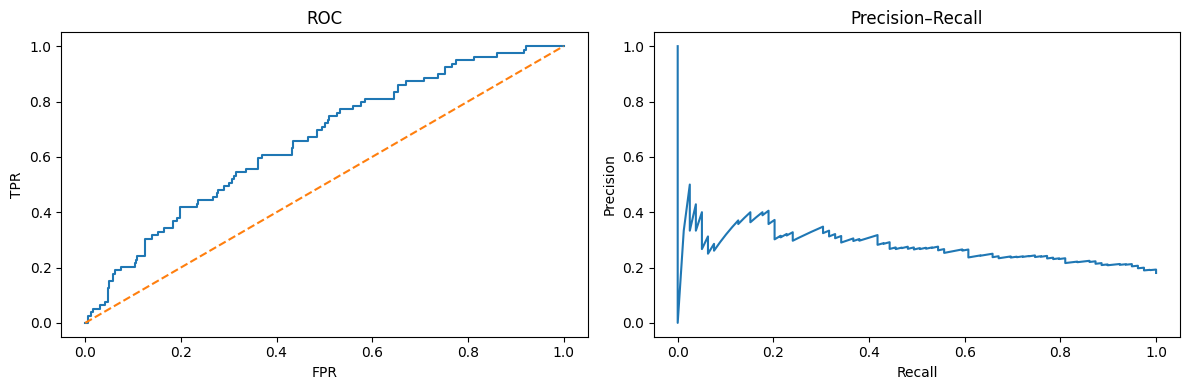

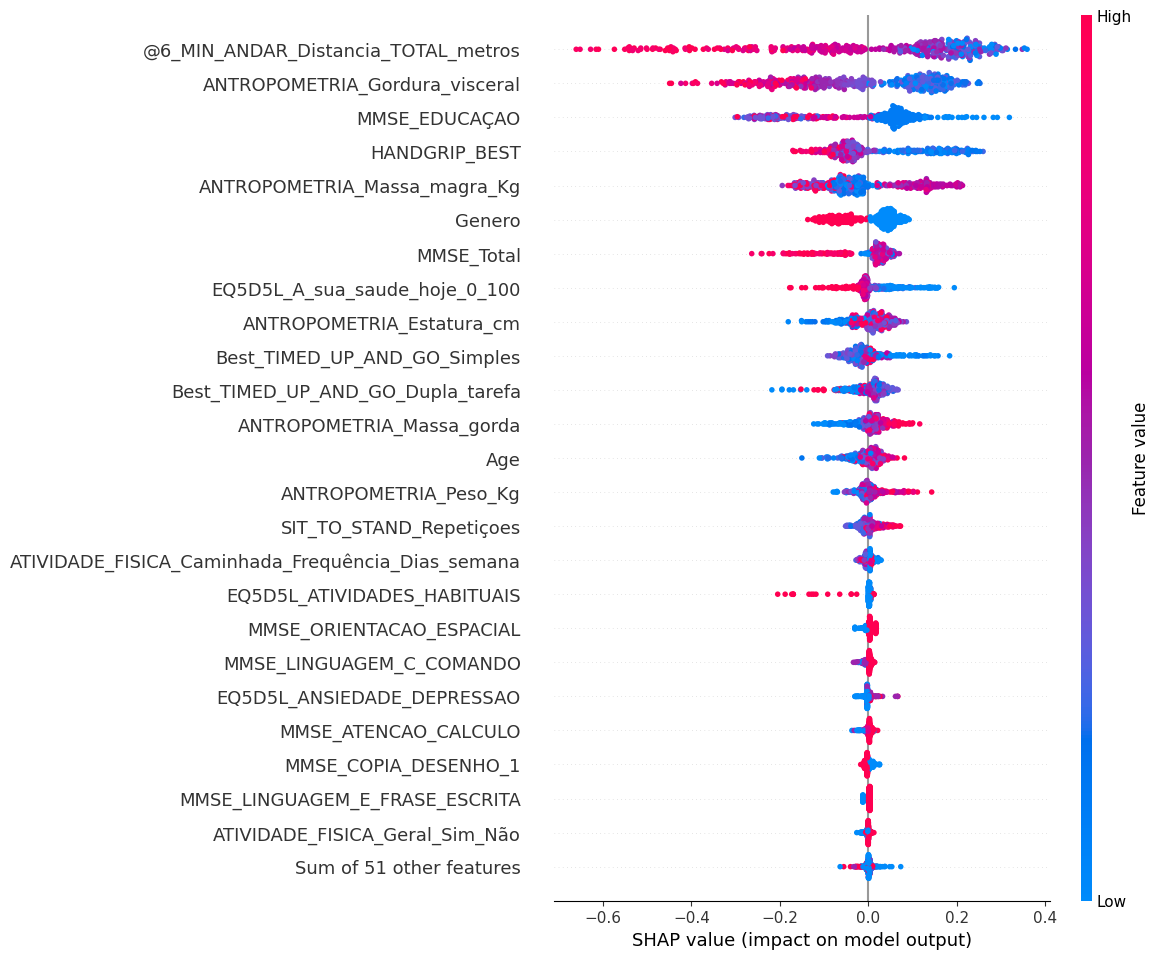

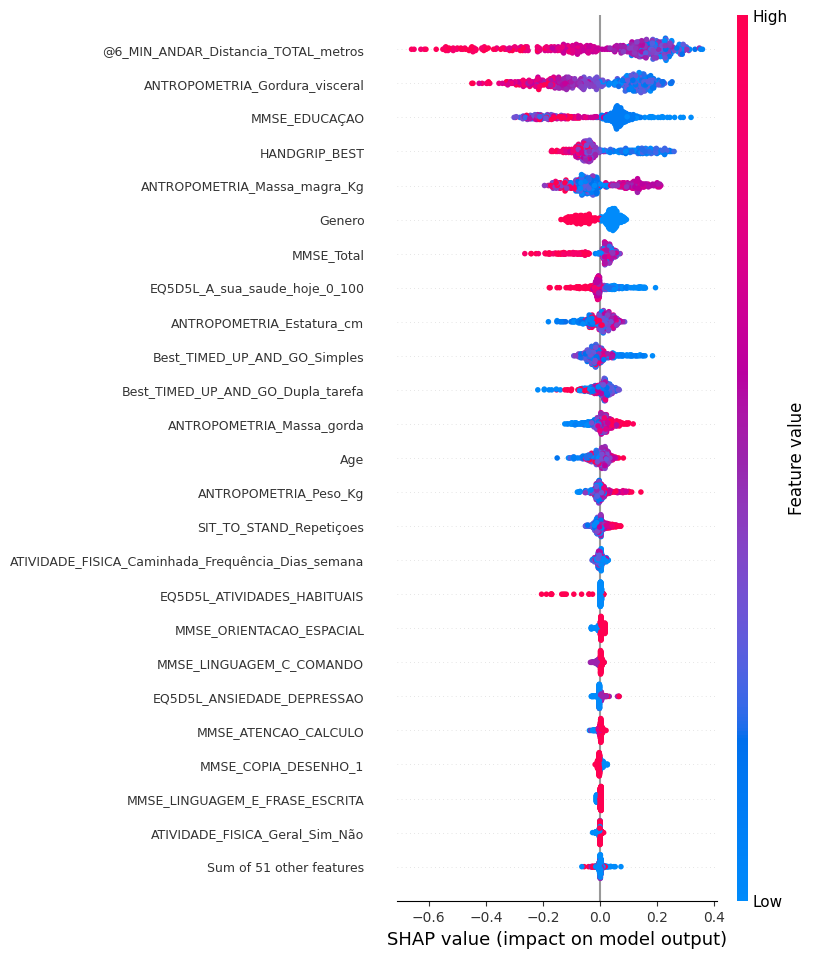

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
from sklearn import __version__ as skver
from packaging.version import Version

import xgboost as xgb
import shap


# 0) Split train/val

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 1) Pré-processamento (imputação + OHE)

# OHE compatível com versão do sklearn
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Ajusta no train, transforma train e val
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Nomes das features após o transform
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]


# 2) XGBoost via API nativa com Early Stopping

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())

dtrain = xgb.DMatrix(X_train_t, label=y_train, feature_names=feat_names)
dval   = xgb.DMatrix(X_val_t,   label=y_val,   feature_names=feat_names)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",       # usar "aucpr" se preferires otimizar PR-AUC
    "eta": 0.02,                # learning_rate
    "max_depth": 4,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "min_child_weight": 1.0,
    "tree_method": "hist",
    "seed": 42,
    "scale_pos_weight": neg / max(pos, 1),
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=100,
    verbose_eval=False
)

print("Best iteration:", bst.best_iteration)
print("Best score (val):", bst.best_score)


# 3) Métricas 

proba = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
pred05 = (proba >= 0.5).astype(int)

print("\n--- Métricas @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Melhor limiar por F1 na validação
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix  = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @0.5\n", confusion_matrix(y_val, pred05))
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))


# 4) Curvas ROC e PR

fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")
plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.tight_layout(); plt.show()

# SHAP para XGBoost Booster 
import shap, xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

# 1) Corrigir o atributo interno base_score
try:
    bst.set_attr(base_score="0.5")
except Exception as e:
    print("Aviso: não consegui set_attr(base_score). A continuar assim mesmo.", e)

# 2) Tenta primeiro o TreeExplainer rápido
try:
    bg_idx = np.random.RandomState(42).choice(
        X_train_t.shape[0], size=min(1000, X_train_t.shape[0]), replace=False
    )
    explainer = shap.TreeExplainer(bst, data=X_train_t[bg_idx], feature_names=feat_names)
    sv = explainer(X_val_t, check_additivity=False)

except Exception as e:
    print("TreeExplainer falhou, a usar fallback Explainer genérico. Motivo:", repr(e))
    # Fallback robusto: passa uma função de previsão; evita parse de atributos internos
    pred_fn = lambda X: bst.predict(
        xgb.DMatrix(X, feature_names=feat_names),
        iteration_range=(0, bst.best_iteration + 1)
    )
    bg_idx = np.random.RandomState(42).choice(
        X_train_t.shape[0], size=min(1000, X_train_t.shape[0]), replace=False
    )
    explainer = shap.Explainer(pred_fn, X_train_t[bg_idx])
    sv = explainer(X_val_t)

sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names,
)
shap.plots.beeswarm(sv, max_display=25)
# 3) Beeswarm (aumentar margem para labels longas)
plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv, max_display=25, show=False)
plt.yticks(fontsize=9); plt.xticks(fontsize=10); plt.subplots_adjust(left=0.40)
plt.show()


## CatBoost

Best iteration: 49
Best score (val): {'learn': {'Logloss': 0.5649970875174183}, 'validation': {'Logloss': 0.6525714397442604, 'AUC': 0.6738478897076972}}

--- Metrics @0.5 ---
AUROC   : 0.674
PR-AUC  : 0.308
Acc@0.5 : 0.644
F1@0.5  : 0.371

--- Threshold tuning ---
Best threshold (by F1): 0.506
F1@best: 0.395

Confusion @best
 [[251 108]
 [ 33  46]]

Classification report @best
              precision    recall  f1-score   support

           0      0.884     0.699     0.781       359
           1      0.299     0.582     0.395        79

    accuracy                          0.678       438
   macro avg      0.591     0.641     0.588       438
weighted avg      0.778     0.678     0.711       438



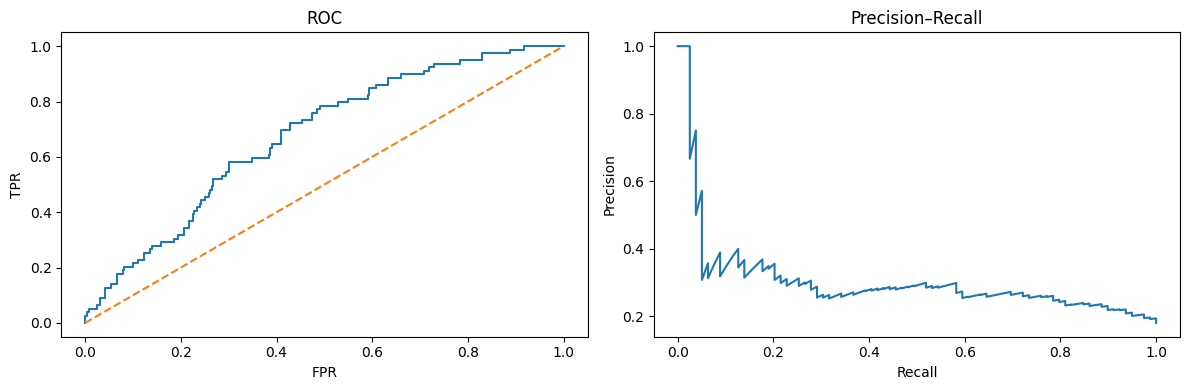

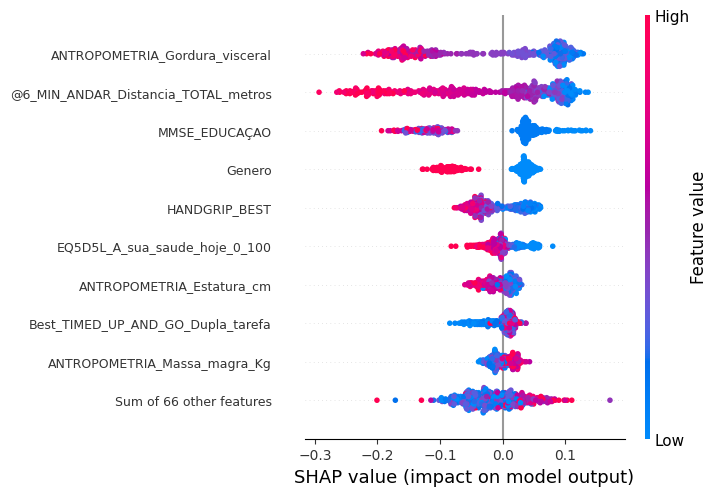

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Standard Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
from sklearn import __version__ as skver
from packaging.version import Version
from catboost import CatBoostClassifier, Pool
import shap

# 0) Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 1) Pre-processing 
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names for SHAP
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# 2) CatBoost Training
clf = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=6,                 # Standard depth, increase to 8 if underfitting
    loss_function='Logloss',
    eval_metric='AUC',       # Optimizing for AUROC
    early_stopping_rounds=100,
    auto_class_weights='Balanced', # Automatically fixes the imbalance
    verbose=0,               # Silent training
    random_seed=42
)


clf.fit(
    X_train_t, y_train,
    eval_set=(X_val_t, y_val),
    use_best_model=True
)

print("Best iteration:", clf.get_best_iteration())
print("Best score (val):", clf.get_best_score())


# 3) Metrics & Threshold Tuning

proba = clf.predict_proba(X_val_t)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Find best threshold by F1 score
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix  = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))


# 4) Plotting Curves

fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")

plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.tight_layout(); plt.show()

# 5) SHAP for CatBoost


explainer = shap.TreeExplainer(clf)
sv = explainer(X_val_t)


sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names
)

plt.close("all")
fig, ax = plt.subplots(figsize=(12, 6))
shap.plots.beeswarm(sv, max_display=10, show=False)
plt.yticks(fontsize=9)
plt.xticks(fontsize=10)
plt.subplots_adjust(left=0.40)
plt.show()

LightGBM was test but it dot provide any useful insight than xgboost, and much worse than catboost

## Explainable Boosting Machine

Training EBM... (This might take a moment)

--- Metrics @0.5 ---
AUROC   : 0.649
PR-AUC  : 0.259
Acc@0.5 : 0.815
F1@0.5  : 0.024

--- Threshold tuning ---
Best threshold (by F1): 0.118
F1@best: 0.376

Confusion @best
 [[127 232]
 [  7  72]]

Classification report @best
              precision    recall  f1-score   support

           0      0.948     0.354     0.515       359
           1      0.237     0.911     0.376        79

    accuracy                          0.454       438
   macro avg      0.592     0.633     0.446       438
weighted avg      0.820     0.454     0.490       438



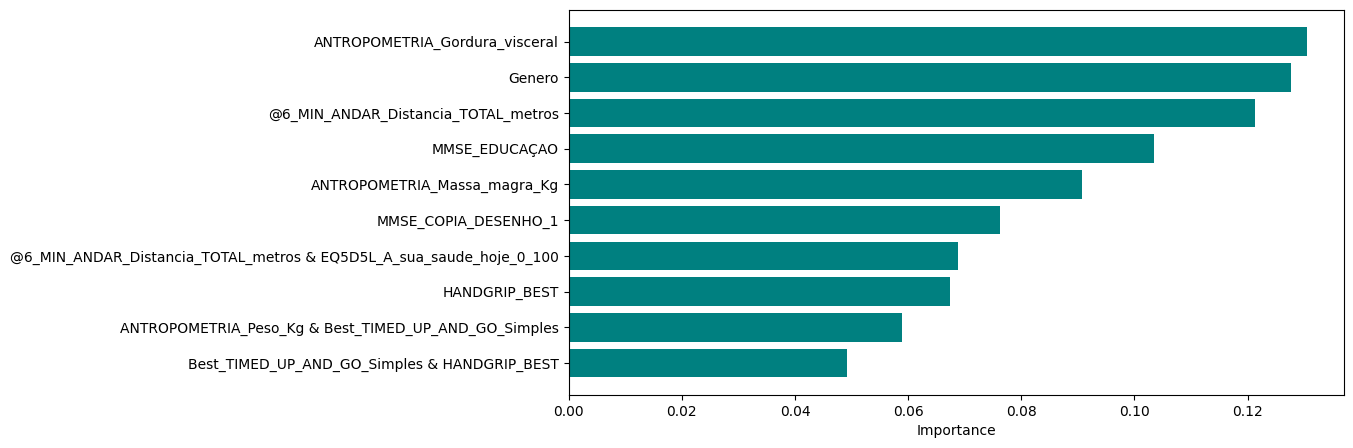

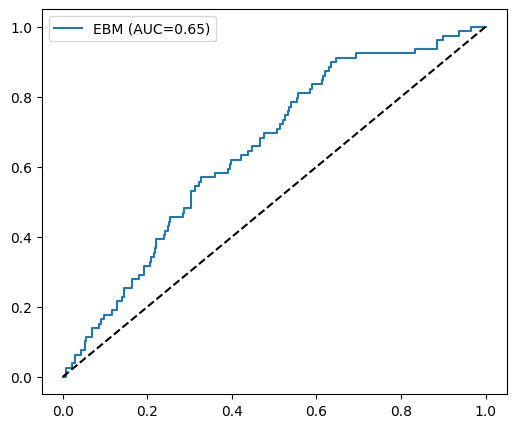

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
from sklearn import __version__ as skver
from packaging.version import Version

# EBM Imports
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show


# 0) Split train/val

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 1) Pre-processing
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names (Crucial for EBM graphs)
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]


# 2) EBM Training

print("Training EBM... (This might take a moment)")

# EBM is a "Generalized Additive Model" with Boosting interactions
ebm = ExplainableBoostingClassifier(
    feature_names=feat_names,
    interactions=10,       # Automatically detects top 10 pair-interactions
    outer_bags=8,          # Ensembling (smoothing)
    inner_bags=0,
    learning_rate=0.01, 
    max_rounds=2000,       # Similar to n_estimators
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1              # Use all cores
)

ebm.fit(X_train_t, y_train)


# 3) Metrics & Threshold Tuning

proba = ebm.predict_proba(X_val_t)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Threshold Tuning
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix  = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))


# 4) Global Explanation 

# This creates a dashboard object. In a notebook, run the next line in a separate cell to see the interactive plots:
# show(ebm_global)

ebm_global = ebm.explain_global()

# For this script, we will extract the top feature importances manually
importances = ebm_global.data()['scores']
names = ebm_global.data()['names']

imp_df = pd.DataFrame({'feature': names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"EBM (AUC={roc_auc_score(y_val, proba):.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()

plt.show()

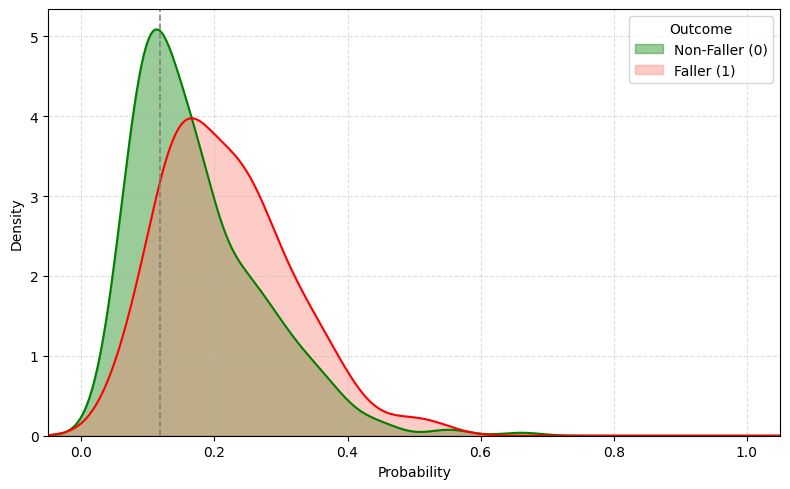

In [17]:
# 5) Density Distribution of Predicted Probabilities

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(8, 5))

proba_0 = proba[y_val == 0]
proba_1 = proba[y_val == 1]

x_grid = np.linspace(-0.05, 1.05, 300)

kde_0 = gaussian_kde(proba_0)
kde_1 = gaussian_kde(proba_1)

ax.fill_between(x_grid, kde_0(x_grid), alpha=0.4, color="green", label="Non-Faller (0)")
ax.plot(x_grid, kde_0(x_grid), color="green", linewidth=1.5)

ax.fill_between(x_grid, kde_1(x_grid), alpha=0.4, color="salmon", label="Faller (1)")
ax.plot(x_grid, kde_1(x_grid), color="red", linewidth=1.5)

ax.axvline(best_thr, color="gray", linestyle="--", linewidth=1.2)

ax.set_xlabel("Probability")
ax.set_ylabel("Density")
ax.legend(title="Outcome")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("ebm_density_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()




# SVM



Training SVM with RBF Kernel...

--- Metrics @0.5 ---
AUROC   : 0.668
PR-AUC  : 0.280
Acc@0.5 : 0.820
F1@0.5  : 0.000

--- Threshold tuning ---
Best threshold (by F1): 0.193
F1@best: 0.403

Confusion @best
 [[252 107]
 [ 32  47]]

Classification report @best
              precision    recall  f1-score   support

           0      0.887     0.702     0.784       359
           1      0.305     0.595     0.403        79

    accuracy                          0.683       438
   macro avg      0.596     0.648     0.594       438
weighted avg      0.782     0.683     0.715       438



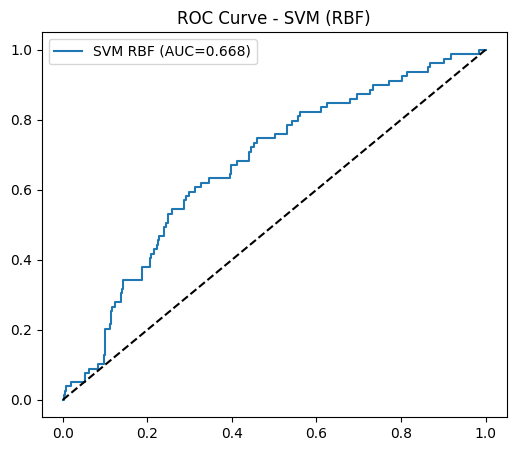

c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(



Calculating SHAP values (KernelExplainer is slow, please wait)...


  0%|          | 0/438 [00:00<?, ?it/s]c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
  0%|          | 1/438 [00:00<07:00,  1.04it/s]c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
  0%|     

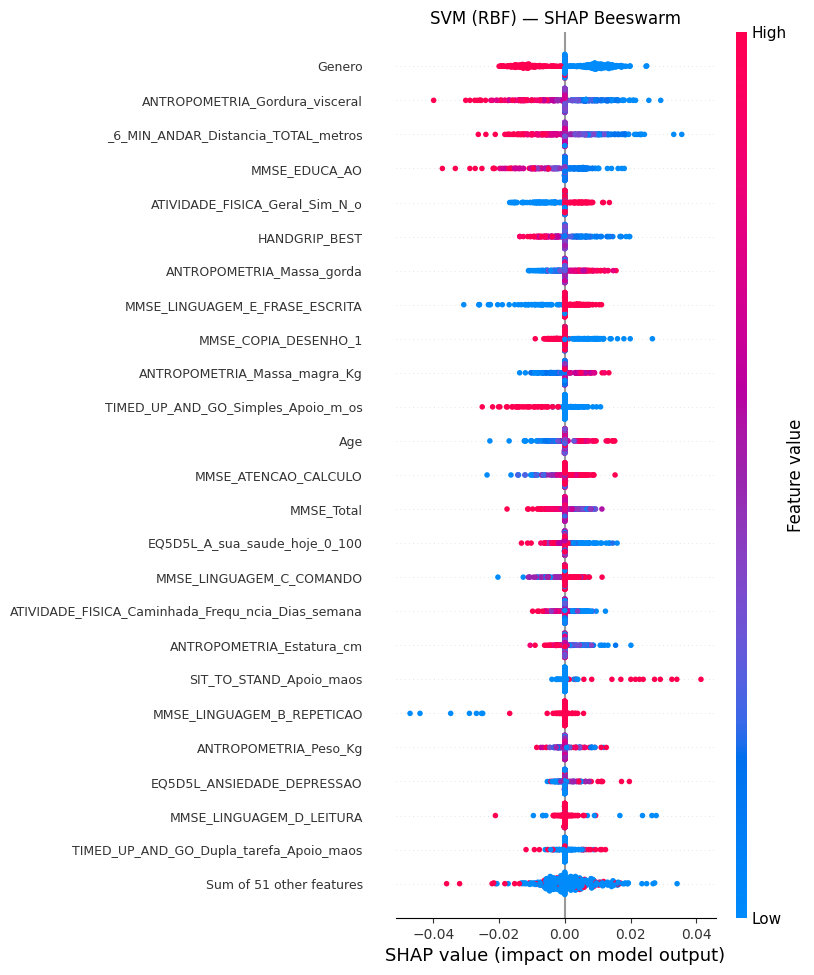

In [9]:
# SVM (RBF) + Metrics + SHAP Beeswarm


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Model
from sklearn.svm import SVC

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, average_precision_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
from sklearn import __version__ as skver
from packaging.version import Version

import shap


# 0) Data Split

# Using stratify to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 1) Pre-processing (StandardScaler is Mandatory for SVM)

def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        # SVM requires data to be scaled (mean=0, var=1)
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()) 
        ]), num_cols),
        
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and Transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Feature Naming & Cleaning
try:
    raw_names = pre.get_feature_names_out().tolist()
except:
    raw_names = [f"f{i}" for i in range(X_train_t.shape[1])]

clean_names = []
used = set()
for n in raw_names:
    # Sanitize names (replace special chars with _)
    s = re.sub(r'[^A-Za-z0-9_]+', '_', n)
    k = s if s not in used else f"{s}_dup"
    i = 1
    while k in used: # Ensure absolute uniqueness
        k = f"{s}_{i}"
        i += 1
    used.add(k)
    clean_names.append(k)

# Convert to DataFrames for easier SHAP handling
X_train_df = pd.DataFrame(X_train_t, columns=clean_names)
X_val_df   = pd.DataFrame(X_val_t, columns=clean_names)

# =======================
# 2) Train SVM (RBF)
# =======================
print("Training SVM with RBF Kernel...")
# probability=True is required for SHAP to explain probabilities
# class_weight='balanced' handles the imbalanced medical data
model_svm = SVC(
    kernel='rbf', 
    probability=True, 
    class_weight='balanced', 
    C=1.0, 
    random_state=42
)
model_svm.fit(X_train_df, y_train)

# =======================
# 3) Metrics & Threshold Tuning
# =======================
# SVM probabilities
proba = model_svm.predict_proba(X_val_df)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Tune Threshold for Best F1
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# Plot ROC
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM RBF (AUC={roc_auc_score(y_val, proba):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - SVM (RBF)")
plt.legend()
plt.show()

# =======================
# 4) SHAP Beeswarm (KernelExplainer)
# =======================
print("\nCalculating SHAP values (KernelExplainer is slow, please wait)...")

# NOTE: SVM does not support TreeExplainer. We use KernelExplainer.
# To make it faster, we summarize the background data (X_train) to 100 samples.
background_data = shap.sample(X_train_df, 100, random_state=42)

# Define a generic prediction function for probability of class 1
def predict_proba_fn(data):
    return model_svm.predict_proba(data)[:, 1]

explainer = shap.KernelExplainer(predict_proba_fn, background_data)

# Explain the validation set (or a sample of it if it's too large)
# Given ~500 rows, this might take 1-3 minutes.
shap_values = explainer.shap_values(X_val_df, nsamples=100) # nsamples controls precision/speed

# Prepare explanation object
# KernelExplainer returns a 1D array per sample because we used a custom function returning 1D output
# If it returns a list (one for each class), take index 1.
# Based on the wrapper above, it returns the values directly.

sv = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_val_df,
    feature_names=clean_names
)

# Plot Beeswarm
plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv, max_display=25, show=False)
plt.yticks(fontsize=9); plt.xticks(fontsize=10); plt.subplots_adjust(left=0.40)
plt.title("SVM (RBF) — SHAP Beeswarm")
plt.show()

## Neural Network (MLP)

Training Neural Network...
Epoch 1/100


c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.5347 - loss: 0.9042 - val_auc: 0.5996 - val_loss: 0.8625
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5529 - loss: 0.8576 - val_auc: 0.6299 - val_loss: 0.8018
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5600 - loss: 0.8425 - val_auc: 0.6667 - val_loss: 0.7537
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5651 - loss: 0.8301 - val_auc: 0.6708 - val_loss: 0.7577
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5836 - loss: 0.7977 - val_auc: 0.6832 - val_loss: 0.7307
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6068 - loss: 0.7780 - val_auc: 0.6939 - val_loss: 0.7273
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6021 - loss: 0.7859 - val_auc: 0.6854 - val_loss: 0.7350
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.6300 - loss: 0.7622 - val_auc: 0.6904 - val_loss: 0.7377
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6313 - loss: 0.7

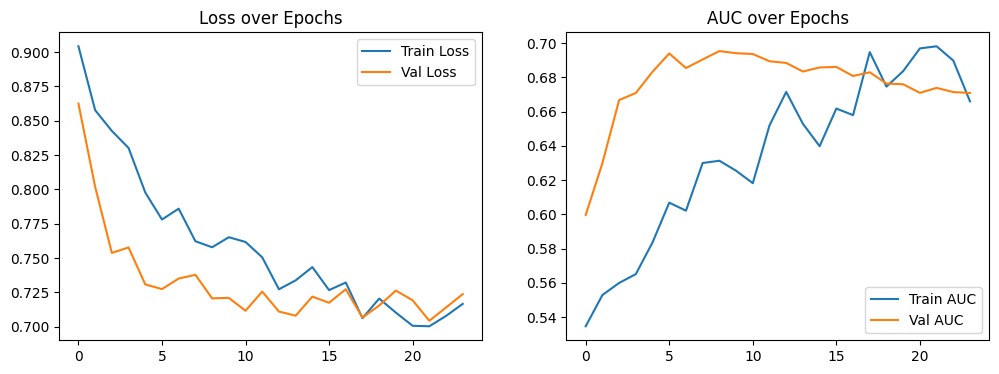

In [10]:

# Neural Network (MLP) for Tabular Data


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve,
    f1_score, accuracy_score,
    average_precision_score   # <-- ADD THIS
)
from sklearn import __version__ as skver
from packaging.version import Version
import re


# 0) Data Split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 1) Pre-processing (Must use Scaling for NN)

def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)


# 2) Define the Neural Network Structure

def build_model(input_dim):
    model = models.Sequential()

    model.add(layers.Dense(64, input_dim=input_dim, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model


# 3) Train with Early Stopping

print("Training Neural Network...")

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
total = pos + neg
w0 = (1 / neg) * (total / 2.0)
w1 = (1 / pos) * (total / 2.0)
class_weights = {0: w0, 1: w1}

model = build_model(X_train_t.shape[1])

early_stop = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)


# 4) Detailed Results & Metrics

proba_nn = model.predict(X_val_t).flatten()

print("\n--- Neural Network Performance Analysis ---")
nn_auc = roc_auc_score(y_val, proba_nn)
nn_pr_auc = average_precision_score(y_val, proba_nn)  # <-- ADD THIS

print(f"AUROC : {nn_auc:.3f}")
print(f"PR-AUC: {nn_pr_auc:.3f}")  # <-- ADD THIS

# Find Best Threshold (maximizing F1)
prec, rec, thr = precision_recall_curve(y_val, proba_nn)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
ix = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5

print(f"Best Threshold (by F1): {best_thr:.3f}")

preds_nn = (proba_nn >= best_thr).astype(int)

cm = confusion_matrix(y_val, preds_nn)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
accuracy = accuracy_score(y_val, preds_nn)
f1 = f1_score(y_val, preds_nn)

print("\n--- Detailed Metrics ---")
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity         : {specificity:.3f}")
print(f"Precision           : {precision:.3f}")
print(f"F1 Score            : {f1:.3f}")
print(f"Accuracy            : {accuracy:.3f}")

print("\nConfusion Matrix:")
print(cm)
print(f"[TN: {tn}, FP: {fp}]")
print(f"[FN: {fn}, TP: {tp}]")

print("\nClassification Report:")
print(classification_report(y_val, preds_nn, digits=3))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC over Epochs')
plt.legend()
plt.show()


## Statistical Comparison Between Models

In [11]:

# COMPARAÇÃO ESTATÍSTICA DE MODELOS (10-FOLD CV)


import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn import __version__ as skver
from packaging.version import Version
import re
import warnings


warnings.filterwarnings('ignore')


# 1. Preparação dos Dados (Scaling Universal)

# Para comparação justa, vamos usar o pipeline que inclui Scaling (necessário para SVM)
# Árvores não são afetadas negativamente pelo scaling.

def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()) # Standard scaling para todos
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


X_processed = preprocessor.fit_transform(X)


try:
    raw_names = preprocessor.get_feature_names_out().tolist()
except:
    raw_names = [f"f{i}" for i in range(X_processed.shape[1])]

feature_names = []
used = set()
for n in raw_names:
    s = re.sub(r'[^A-Za-z0-9_]+', '_', n)
    k = s if s not in used else f"{s}_dup"
    i = 1
    while k in used:
        k = f"{s}_{i}"
        i += 1
    used.add(k)
    feature_names.append(k)


X_df = pd.DataFrame(X_processed, columns=feature_names)
y_series = pd.Series(y).reset_index(drop=True)


# 2. Definição dos Modelos

# Configurações otimizadas das etapas anteriores

# Pesos para balanceamento (Global)
pos = int((y_series == 1).sum())
neg = int((y_series == 0).sum())
scale_pos_weight = neg / max(pos, 1)

models = {
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="auc", 
        n_estimators=1000, learning_rate=0.02, max_depth=4, 
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=1000, learning_rate=0.02, depth=6, eval_metric='AUC',
        auto_class_weights='Balanced', verbose=0, random_seed=42, allow_writing_files=False
    ),
    "EBM": ExplainableBoostingClassifier(
        feature_names=feature_names, interactions=10, outer_bags=8, 
        learning_rate=0.01, max_rounds=1000, random_state=42, n_jobs=1
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', probability=True, class_weight='balanced', 
        C=1.0, random_state=42
    )
}

# 3. Loop de 10-Fold CV

print("A iniciar 10-Fold Cross-Validation...")
print("Isto pode demorar alguns minutos devido ao treino repetido.")

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Dicionário para guardar os scores de cada fold
cv_results = {name: [] for name in models.keys()}
cv_results["Ensemble"] = []

fold = 1
for train_idx, val_idx in kf.split(X_df, y_series):
    X_tr, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
    y_tr, y_val = y_series.iloc[train_idx], y_series.iloc[val_idx]
    
    fold_probs = [] # Para guardar probs deste fold para o ensemble
    
    # Treinar cada modelo individualmente
    for name, model in models.items():
        # Clone ou re-instanciar seria ideal, mas fit() geralmente reinicia
        try:
            model.fit(X_tr, y_tr)
        except:
            # Fallback para EBM/CatBoost se precisarem de eval_set específico
            model.fit(X_tr, y_tr)
            
        # Predição
        if name == "SVM (RBF)" or name == "EBM":
            p = model.predict_proba(X_val)[:, 1]
        else:
            p = model.predict_proba(X_val)[:, 1]
            
        auc = roc_auc_score(y_val, p)
        cv_results[name].append(auc)
        fold_probs.append(p)
    
    # Calcular Ensemble deste fold (Média Simples)
    ens_p = np.mean(fold_probs, axis=0)
    ens_auc = roc_auc_score(y_val, ens_p)
    cv_results["Ensemble"].append(ens_auc)
    
    print(f"Fold {fold}/10 Concluído - Ensemble AUC: {ens_auc:.3f}")
    fold += 1


# 4. Análise Estatística 

print("\n" + "="*60)
print("RESULTADOS DA COMPARAÇÃO ESTATÍSTICA PAR-A-PAR")
print("="*60)
print(f"{'Comparação':<30} | {'Diferença Média':<15} | {'Teste Usado':<20} | {'p-value':<10} | {'Significativo?'}")
print("-" * 100)

model_names = list(cv_results.keys())
significant_findings = []

# Iterar por todos os pares únicos
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        
        scores_a = np.array(cv_results[name_a])
        scores_b = np.array(cv_results[name_b])
        
        # Diferenças (Fold a Fold)
        diff = scores_a - scores_b
        mean_diff = np.mean(diff)
        
        # 1. Teste de Normalidade (Shapiro-Wilk) nas diferenças
        # Se p > 0.05, assumimos normalidade
        shapiro_stat, shapiro_p = stats.shapiro(diff)
        is_normal = shapiro_p > 0.05
        
        # 2. Escolha do Teste
        if is_normal:
            # Paramétrico: Paired t-test
            test_stat, p_val = stats.ttest_rel(scores_a, scores_b)
            test_name = "Paired t-test"
        else:
            # Não-Paramétrico: Wilcoxon Signed-Rank
            test_stat, p_val = stats.wilcoxon(scores_a, scores_b)
            test_name = "Wilcoxon"
            
        is_sig = "SIM" if p_val < 0.05 else "Não"
        
        print(f"{name_a} vs {name_b:<18} | {mean_diff:+.4f}          | {test_name:<20} | {p_val:.4f}     | {is_sig}")
        
        if p_val < 0.05:
            winner = name_a if mean_diff > 0 else name_b
            significant_findings.append(f"-> {winner} é estatisticamente superior a {name_a if winner == name_b else name_b} (p={p_val:.4f})")

print("\nRESUMO DAS DESCOBERTAS SIGNIFICATIVAS (p < 0.05):")
if not significant_findings:
    print("Nenhuma diferença estatisticamente significativa encontrada entre os modelos.")
    print("Isto sugere que os modelos têm desempenhos muito semelhantes (overlapping confidence intervals).")
else:
    for finding in significant_findings:
        print(finding)

# Mostrar médias finais
print("\nMédias de AUC (10-Folds):")
metrics_df = pd.DataFrame(cv_results)
print(metrics_df.mean().sort_values(ascending=False))

A iniciar 10-Fold Cross-Validation...
Isto pode demorar alguns minutos devido ao treino repetido.
Fold 1/10 Concluído - Ensemble AUC: 0.674
Fold 2/10 Concluído - Ensemble AUC: 0.615
Fold 3/10 Concluído - Ensemble AUC: 0.609
Fold 4/10 Concluído - Ensemble AUC: 0.620
Fold 5/10 Concluído - Ensemble AUC: 0.581
Fold 6/10 Concluído - Ensemble AUC: 0.648
Fold 7/10 Concluído - Ensemble AUC: 0.600
Fold 8/10 Concluído - Ensemble AUC: 0.688
Fold 9/10 Concluído - Ensemble AUC: 0.716
Fold 10/10 Concluído - Ensemble AUC: 0.581

RESULTADOS DA COMPARAÇÃO ESTATÍSTICA PAR-A-PAR
Comparação                     | Diferença Média | Teste Usado          | p-value    | Significativo?
----------------------------------------------------------------------------------------------------
XGBoost vs CatBoost           | -0.0175          | Paired t-test        | 0.0804     | Não
XGBoost vs EBM                | -0.0312          | Paired t-test        | 0.0499     | SIM
XGBoost vs SVM (RBF)          | -0.0033         

## Reciprocal Rank Fusion Score

A treinar 5 modelos para RRF (todos em X_val_t)...
 -> XGBoost
 -> CatBoost
 -> EBM
 -> SVM
 -> MLP

AUC do RRF: 0.655


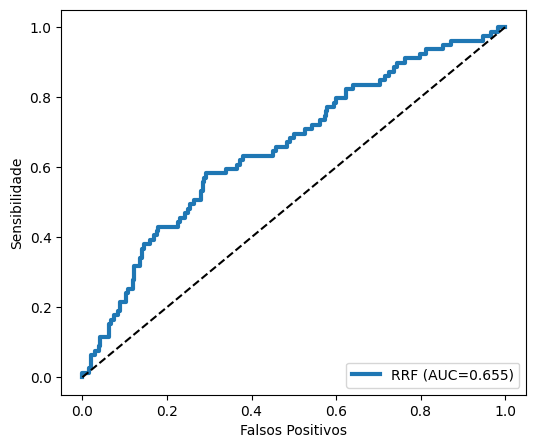

,Real_Caiu,Prob_XGBoost,Prob_CatBoost,Prob_EBM,Prob_SVM,Prob_MLP,RRF_Score,Rank_XGBoost,Rank_CatBoost,Rank_EBM,Rank_SVM,Rank_MLP,Risco_Consenso_Pct
440,1,0.844592,0.859400,0.408602,0.354869,0.297808,0.077119,6,2,11,4,2,100.000000
1125,0,0.870660,0.751902,0.459232,0.232420,0.233406,0.064160,1,7,6,92,30,80.621036
1473,0,0.869673,0.898111,0.549408,0.295110,0.112391,0.063571,3,1,3,17,349,79.740350
999,0,0.447420,0.657614,0.455156,0.293008,0.278035,0.062605,85,19,7,20,4,78.295272
1158,0,0.870484,0.716658,0.423512,0.303707,0.171739,0.062089,2,14,9,13,175,77.523768
1623,0,0.722696,0.776071,0.347641,0.357737,0.200203,0.060906,21,6,32,2,96,75.754362
928,0,0.785646,0.628211,0.260888,0.285389,0.284192,0.060588,10,24,85,26,3,75.278666
1952,1,0.706073,0.678433,0.387346,0.368362,0.185751,0.059721,24,17,15,1,136,73.981582
1581,0,0.769858,0.806230,0.356778,0.294930,0.171903,0.058589,13,3,24,18,173,72.289004
475,1,0.593424,0.586782,0.369748,0.277509,0.246005,0.056783,43,31,21,33,17,69.588781


In [12]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn import __version__ as skver
from packaging.version import Version


# -----------------------------
# 0) Split (único e consistente)
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Garantir Series + índice alinhado
if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train, index=X_train.index)
if not isinstance(y_val, pd.Series):
    y_val = pd.Series(y_val, index=X_val.index)

assert X_val.index.equals(y_val.index), "X_val e y_val não estão alinhados por índice."


# -----------------------------
# 1) Preprocess (impute + OHE)
# -----------------------------
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Feature names para EBM
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# Checks de segurança
assert X_train_t.shape[0] == len(y_train), "X_train_t e y_train com tamanhos diferentes."
assert X_val_t.shape[0] == len(y_val), "X_val_t e y_val com tamanhos diferentes."


# -----------------------------
# 2) Modelos (RRF: XGB + Cat + EBM + SVM + MLP)
# -----------------------------
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models_dict = {
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        eval_metric="AUC",
        auto_class_weights="Balanced",
        verbose=0,
        allow_writing_files=False,
        random_seed=42
    ),
    "EBM": ExplainableBoostingClassifier(
        feature_names=feat_names,
        interactions=10,
        outer_bags=8,
        inner_bags=0,
        learning_rate=0.01,
        max_rounds=2000,
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, probability=True, class_weight="balanced"))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=64,
            learning_rate_init=1e-3,
            max_iter=300,
            early_stopping=True,
            n_iter_no_change=20,
            random_state=42
        ))
    ])
}


# -----------------------------
# 3) Treinar + Probabilidades (sempre em X_*_t)
# -----------------------------
df_preds = pd.DataFrame(index=X_val.index)
df_preds["Real_Caiu"] = y_val.astype(int).values

print(f"A treinar {len(models_dict)} modelos para RRF (todos em X_val_t)...")

for name, model in models_dict.items():
    print(f" -> {name}")
    model.fit(X_train_t, y_train.values)
    probs = model.predict_proba(X_val_t)[:, 1]

    if len(probs) != len(df_preds):
        raise ValueError(f"[{name}] len(probs)={len(probs)} != len(X_val)={len(df_preds)}")

    df_preds[f"Prob_{name}"] = probs


# -----------------------------
# 4) RRF (consenso por ranking)
# -----------------------------
k = 60
df_preds["RRF_Score"] = 0.0

for name in models_dict.keys():
    r = stats.rankdata(-df_preds[f"Prob_{name}"].values, method="min")  # maior prob = rank 1
    df_preds[f"Rank_{name}"] = r
    df_preds["RRF_Score"] += 1.0 / (k + r)

# Normalizar para percentil 0-100
min_s = df_preds["RRF_Score"].min()
max_s = df_preds["RRF_Score"].max()
df_preds["Risco_Consenso_Pct"] = 100.0 * (df_preds["RRF_Score"] - min_s) / (max_s - min_s + 1e-12)

df_final = df_preds.sort_values("RRF_Score", ascending=False)


# -----------------------------
# 5) Avaliação (ROC/AUC) + Top riscos
# -----------------------------
auc_rrf = roc_auc_score(df_final["Real_Caiu"], df_final["RRF_Score"])
print("\nAUC do RRF:", round(float(auc_rrf), 3))

fpr, tpr, _ = roc_curve(df_final["Real_Caiu"], df_final["RRF_Score"])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"RRF (AUC={auc_rrf:.3f})", lw=3)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("Falsos Positivos")
plt.ylabel("Sensibilidade")
plt.legend(loc="lower right")
plt.show()

# Ver os mais arriscados
display(df_final.head(20))

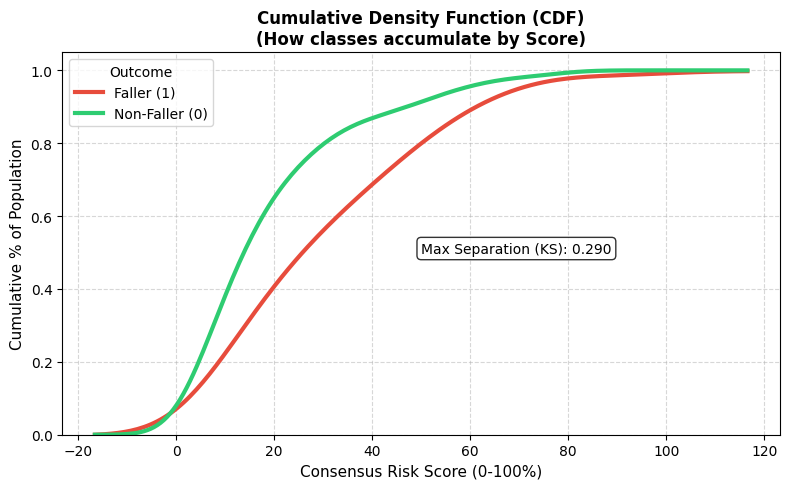

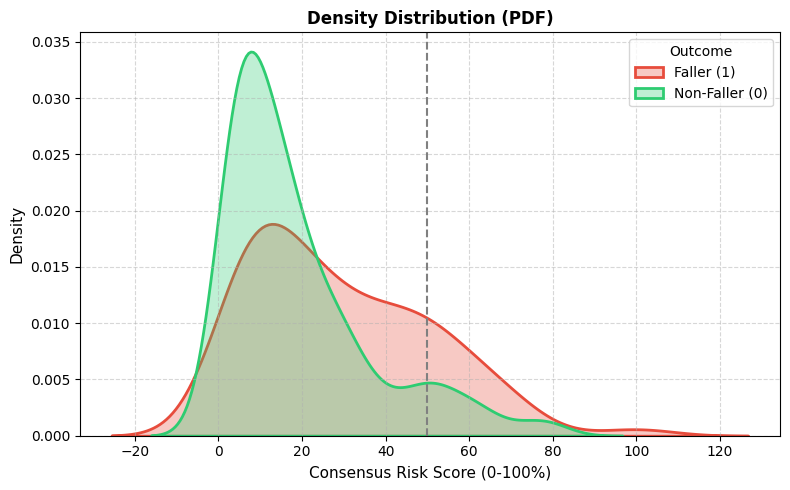

In [13]:

# 5 Cumulative Density & Distribution 

import matplotlib.ticker as mtick
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp


df_final['Real_Caiu'] = df_final['Real_Caiu'].astype(int)


score_col = 'Risco_Consenso_Pct'

# PLOT 1: Cumulative Distribution Function (CDF)

fig1, ax1 = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=df_final,
    x=score_col,
    hue='Real_Caiu',
    cumulative=True,
    common_norm=False,
    common_grid=True,
    palette={0: '#2ecc71', 1: '#e74c3c'},
    linewidth=3,
    ax=ax1
)

ax1.set_title("Cumulative Density Function (CDF)\n(How classes accumulate by Score)",
              fontsize=12, fontweight='bold')
ax1.set_ylabel("Cumulative % of Population", fontsize=11)
ax1.set_xlabel("Consensus Risk Score (0-100%)", fontsize=11)
ax1.legend(title='Outcome', labels=['Faller (1)', 'Non-Faller (0)'], loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# KS statistic (max vertical separation)
score_0 = df_final[df_final['Real_Caiu'] == 0][score_col]
score_1 = df_final[df_final['Real_Caiu'] == 1][score_col]
ks_stat, p_value = ks_2samp(score_0, score_1)

ax1.annotate(
    f'Max Separation (KS): {ks_stat:.3f}',
    xy=(50, 0.5), xycoords='data',
    bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.8)
)

plt.tight_layout()
plt.show()


# PLOT 2: Probability Density Function (PDF)

fig2, ax2 = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=df_final,
    x=score_col,
    hue='Real_Caiu',
    fill=True,
    common_norm=False,
    palette={0: '#2ecc71', 1: '#e74c3c'},
    alpha=0.3,
    linewidth=2,
    ax=ax2
)

ax2.set_title("Density Distribution (PDF)",
              fontsize=12, fontweight='bold')
ax2.set_ylabel("Density", fontsize=11)
ax2.set_xlabel("Consensus Risk Score (0-100%)", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

# Add threshold line (e.g., at 50%)
ax2.axvline(50, color='gray', linestyle='--', label='Cutoff 50%')
ax2.legend(title='Outcome', labels=['Faller (1)', 'Non-Faller (0)'])

plt.tight_layout()
plt.show()
